# OscilloSim quickstart: oscillator dynamics and synchronization

This notebook is a hands-on tour of PRIN's oscillator-simulation surface. You
will learn how to launch a Kuramoto network with one call
(`prin.quick_simulate`) and read its throughput, how to record and plot the
order parameter *R* of an `OscilloSim` trajectory, how to sweep the coupling
strength *K* to locate the synchronization transition, how the four coupling
modes differ, and how to diagnose a chimera state with
`local_order_parameter` / `chimera_index` / `strength_of_incoherence`. Every
number is computed by the Rust core (`prin._prin_core`); the Python layer only
marshals tensors.

**Runtime budget: ~20 s on CPU** (measured 19.9 s end-to-end under `nbclient`
on the maintainer host: Windows, Python 3.14, torch 2.11.0 CPU). No GPU, no
network access, and every random draw is seeded.

**Scale note.** The archived PRINet 3.0 notebook this one is ported from used
N = 10 000 oscillators for the transition sweep and 2 000 steps for the chimera
run. This tutorial uses N = 512 for the sweeps and N = 256 for the chimera so
the whole notebook finishes in seconds — **scale the `n_oscillators` arguments
up freely**; PRIN's throughput section below shows the same call at
N = 100 000. The numbers printed here are a *demonstration of the API at
tutorial scale*, not a measurement of PRIN's critical coupling or chimera
regime. Those come from the governed campaigns behind `prin.simulation_experiments`
and require multiple seeds, transient discard, and finite-size scaling.

**Prerequisites:** `pip install -e ".[all]"` (the `dev` extra supplies the
notebook tooling; `mot` is only needed by notebook 02).

In [1]:
import numpy as np
import torch

import prin
from prin.simulation import (
    bimodality_index,
    chimera_index,
    cosine_coupling_kernel,
    discontinuity_measure,
    local_order_parameter,
    strength_of_incoherence,
)

# `import prin` transitively selects matplotlib's non-interactive Agg backend
# (prin.reporting.figure_generation runs `matplotlib.use("Agg", force=True)` at
# import time), so the inline magic has to come *after* it -- otherwise every
# `plt.show()` below renders to a dead canvas and emits no figure at all.
%matplotlib inline

import matplotlib.pyplot as plt

# Every simulation in this notebook is pinned to CPU so it runs anywhere.
DEVICE = "cpu"

# One seed for the whole notebook; each simulation below also takes it
# explicitly, because PRIN never draws random numbers from a hidden global.
SEED = 42

print(f"prin {prin.__version__} | torch {torch.__version__} | numpy {np.__version__}")
print(f"device: {DEVICE}")

prin 0.3.0 | torch 2.11.0+cu128 | numpy 2.5.1
device: cpu


## 1. One-call simulation and throughput

`prin.quick_simulate` builds an `OscilloSim`, runs it, and returns a
`SimulationResult`. `coupling_mode="auto"` picks the kernel by size — CSR below
1 000 oscillators, sparse k-NN from 1 000 to 100 000, and mean field above
that — which is why the resolved mode printed below changes with N.

The coupling strength is set to K = 8 rather than the default K = 2 on
purpose: PRIN's natural frequencies are in **hertz** (`freq_mean=5.0`,
`freq_std=0.5`), so the phase equation sees a spread of
sigma_omega = 2 pi freq_std ~= 3.14 rad/s. At K = 2 the network is far below
the synchronization threshold and *R* stays at its incoherent floor; K = 8 sits
comfortably above it.

In [2]:
for n in (1_000, 10_000, 100_000):
    res = prin.quick_simulate(
        n_oscillators=n,
        n_steps=200,
        dt=0.01,
        coupling_strength=8.0,
        coupling_mode="auto",
        k_neighbors=8,
        integrator="euler",
        device=DEVICE,
        seed=SEED,
    )
    print(
        f"N={n:>7,}  mode={res.coupling_mode:<10}  R_final={res.order_parameter[-1]:.4f}"
        f"  wall={res.wall_time_s:.3f}s  throughput={res.throughput:>13,.0f} osc-steps/s"
    )

N=  1,000  mode=sparse_knn  R_final=0.7292  wall=0.012s  throughput=   16,503,829 osc-steps/s


N= 10,000  mode=sparse_knn  R_final=0.6620  wall=0.183s  throughput=   10,905,756 osc-steps/s
N=100,000  mode=mean_field  R_final=0.2640  wall=0.476s  throughput=   41,998,931 osc-steps/s


## 2. Inspecting a simulator, and cross-checking *R*

`OscilloSim` is a plain configuration object: nothing is allocated until
`.run()`. `state_summary()` reports the resolved configuration, and the
`coupling_mode` property reports what `"auto"` resolved to for this N.

Two argument combinations are rejected at construction rather than at run time,
which is worth seeing once so the error messages are familiar. Finally, the
order parameter PRIN records is cross-checked against
`prin.kuramoto_order_parameter` computed by hand from `final_phase`.

In [3]:
probe = prin.OscilloSim(n_oscillators=64, coupling_strength=8.0,
                        coupling_mode="auto", device=DEVICE, seed=SEED)
print("state_summary :", probe.state_summary())
print("resolved mode :", probe.coupling_mode)
print("device        :", probe.device)

for label, kwargs in (
    ("coupling_mode='full'", {"coupling_mode": "full"}),
    (
        "coupling_weights with mode 'auto'",
        {"coupling_mode": "auto", "coupling_weights": torch.zeros(64, 8)},
    ),
):
    try:
        prin.OscilloSim(n_oscillators=64, device=DEVICE, seed=SEED, **kwargs)
    except ValueError as exc:
        print(f"rejected: {label} -> ValueError: {exc}")

check = probe.run(n_steps=2_000, dt=0.01)
manual_R = prin.kuramoto_order_parameter(check.final_phase)
print(f"recorded R    : {check.order_parameter[-1]:.10f}")
print(f"manual R      : {float(manual_R):.10f}  (dtype {manual_R.dtype})")
print(f"agreement     : {abs(check.order_parameter[-1] - float(manual_R)) < 1e-6}")

state_summary : {'n_oscillators': 64, 'coupling_mode': 'csr', 'coupling_strength': 8.0, 'mu': 1.0, 'phase_lag': 0.0, 'device': 'cpu', 'dtype': 'torch.float32', 'sparsity': 0.99}
resolved mode : csr
device        : cpu
rejected: coupling_mode='full' -> ValueError: Unknown coupling_mode 'full'; expected one of ['auto', 'csr', 'mean_field', 'ring', 'small_world', 'sparse_knn']
recorded R    : 0.6589895852
manual R      : 0.6589896083  (dtype torch.float32)
agreement     : True


## 3. Synchronization dynamics of one trajectory

`OscilloSim.run` samples the order parameter every `record_interval` steps, and
stores the full phase trajectory when `record_trajectory=True`. Below: *R*(t),
the recorded phase trajectory, and the final-phase histogram of a mean-field
network that relaxes from random initial phases to a synchronized cluster.

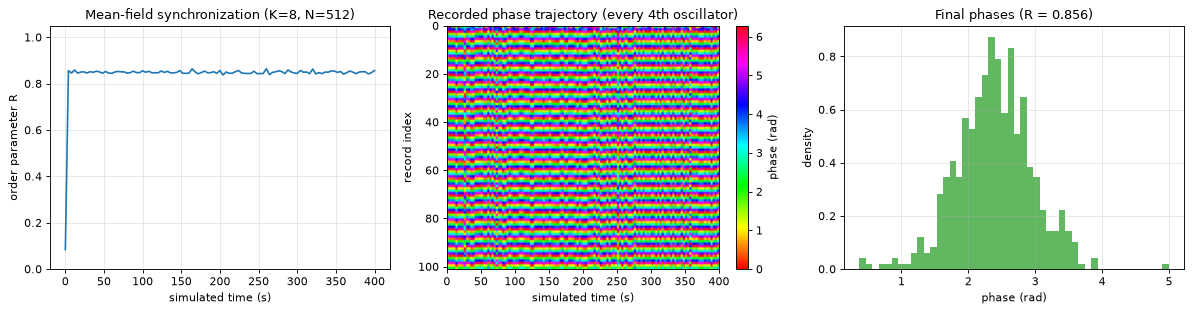

records            : 101
trajectory shape   : (101, 512)
final R            : 0.8564
wall time          : 0.311 s
resolved mode      : mean_field
amplitude range    : [1.0000, 1.0000]


In [4]:
sim = prin.OscilloSim(
    n_oscillators=512,
    coupling_strength=8.0,
    coupling_mode="mean_field",
    integrator="euler",
    device=DEVICE,
    seed=SEED,
)
res = sim.run(n_steps=40_000, dt=0.01, record_trajectory=True, record_interval=400)

n_records = len(res.order_parameter)
t_axis = np.arange(n_records) * 400 * 0.01
final_phase = res.final_phase.numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(t_axis, res.order_parameter, color="#1f77b4")
axes[0].set_xlabel("simulated time (s)")
axes[0].set_ylabel("order parameter R")
axes[0].set_title("Mean-field synchronization (K=8, N=512)")
axes[0].set_ylim(0, 1.05)
axes[0].grid(alpha=0.3)

traj = res.trajectory_phase.numpy()
# Every fourth oscillator, and a reduced dpi: the wrapped-phase pattern is
# visually incompressible, and the stored PNG dominates the notebook size.
traj_thin = traj[:, ::4]
im = axes[1].imshow(
    traj_thin, aspect="auto", cmap="hsv", vmin=0.0, vmax=2 * np.pi,
    extent=[0.0, t_axis[-1], traj_thin.shape[0], 0],
)
axes[1].set_xlabel("simulated time (s)")
axes[1].set_ylabel("record index")
axes[1].set_title("Recorded phase trajectory (every 4th oscillator)")
fig.colorbar(im, ax=axes[1], label="phase (rad)")

axes[2].hist(final_phase, bins=48, density=True, alpha=0.75, color="#2ca02c")
axes[2].set_xlabel("phase (rad)")
axes[2].set_ylabel("density")
axes[2].set_title(f"Final phases (R = {res.order_parameter[-1]:.3f})")
axes[2].grid(alpha=0.3)

fig.set_dpi(80)
plt.tight_layout()
plt.show()
plt.close(fig)

print(f"records            : {n_records}")
print(f"trajectory shape   : {tuple(res.trajectory_phase.shape)}")
print(f"final R            : {res.order_parameter[-1]:.4f}")
print(f"wall time          : {res.wall_time_s:.3f} s")
print(f"resolved mode      : {res.coupling_mode}")
print(f"amplitude range    : [{float(res.final_amplitude.min()):.4f}, "
      f"{float(res.final_amplitude.max()):.4f}]")

## 4. Coupling-strength sweep: locating the transition

For a unimodal, symmetric natural-frequency distribution g(omega), mean-field
Kuramoto theory puts the critical coupling at

```text
K_c = 2 / (pi * g(0)) = 2 * sigma_omega * sqrt(2 / pi)
```

With PRIN's defaults (`freq_std=0.5` Hz, and omega = 2 pi f) that gives
sigma_omega = pi and **K_c ~= 5.01**. The sweep below resolves the onset; the
half-synchronization crossing lands slightly above K_c, which is expected at
finite N and finite integration time.

This is a single-seed, transient-included, N = 512 tutorial sweep. It
demonstrates the API and is consistent with theory in magnitude; it is not a
measurement of PRIN's critical coupling.

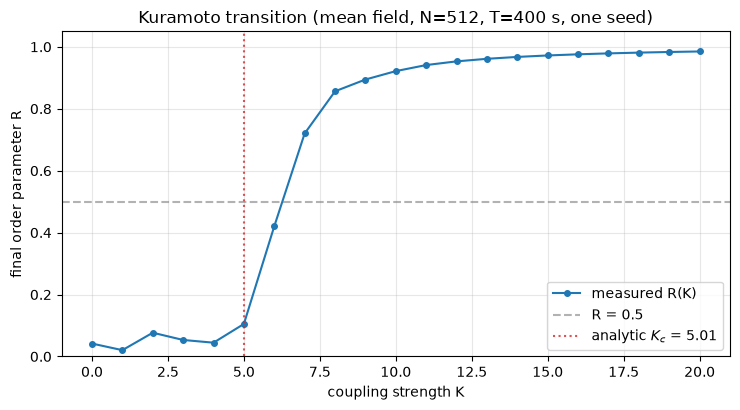

analytic K_c              : 5.013
first grid K with R > 0.5 : 7.00
  K=  0.0  R=0.0418
  K=  1.0  R=0.0204
  K=  2.0  R=0.0768
  K=  3.0  R=0.0534
  K=  4.0  R=0.0446
  K=  5.0  R=0.1051
  K=  6.0  R=0.4206
  K=  7.0  R=0.7202
  K=  8.0  R=0.8564
  K=  9.0  R=0.8944
  K= 10.0  R=0.9215
  K= 11.0  R=0.9411
  K= 12.0  R=0.9530
  K= 13.0  R=0.9613
  K= 14.0  R=0.9674
  K= 15.0  R=0.9721
  K= 16.0  R=0.9758
  K= 17.0  R=0.9788
  K= 18.0  R=0.9812
  K= 19.0  R=0.9833
  K= 20.0  R=0.9850


In [5]:
K_values = np.linspace(0.0, 20.0, 21)
R_final: list[float] = []

for K in K_values:
    sweep_sim = prin.OscilloSim(
        n_oscillators=512,
        coupling_strength=float(K),
        coupling_mode="mean_field",
        integrator="euler",
        device=DEVICE,
        seed=SEED,
    )
    sweep_res = sweep_sim.run(n_steps=40_000, dt=0.01, record_interval=4_000)
    R_final.append(sweep_res.order_parameter[-1])

sigma_omega = 2 * np.pi * 0.5
K_c = 2 * sigma_omega * np.sqrt(2 / np.pi)
above = [K for K, r in zip(K_values, R_final, strict=True) if r > 0.5]
K_half = min(above) if above else float("nan")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(K_values, R_final, "o-", markersize=4, color="#1f77b4", label="measured R(K)")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.6, label="R = 0.5")
ax.axvline(K_c, color="#d62728", linestyle=":", alpha=0.8,
           label=f"analytic $K_c$ = {K_c:.2f}")
ax.set_xlabel("coupling strength K")
ax.set_ylabel("final order parameter R")
ax.set_title("Kuramoto transition (mean field, N=512, T=400 s, one seed)")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()
plt.close(fig)

print(f"analytic K_c              : {K_c:.3f}")
print(f"first grid K with R > 0.5 : {K_half:.2f}")
for K, r in zip(K_values, R_final, strict=True):
    print(f"  K={K:5.1f}  R={r:.4f}")

## 5. Coupling modes compared

`OscilloSim` accepts `"csr"`, `"mean_field"`, `"ring"`, `"small_world"`, and
`"sparse_knn"` (plus `"auto"`, which resolves to one of them). `"full"` is
rejected: a dense all-to-all matrix is exactly what `"mean_field"` computes in
O(N) per step, so PRIN does not materialize it.

At matched K the modes do **not** reach the same *R*. A one-dimensional ring
with only `k_neighbors` local contacts cannot absorb the frequency spread — it
settles into phase-gradient (twisted) states — while any mode that adds
long-range shortcuts does synchronize.

mean_field   resolved=mean_field   R_final=0.9209 wall=0.140s


ring         resolved=ring         R_final=0.1058 wall=0.379s
small_world  resolved=small_world  R_final=0.3684 wall=0.423s
sparse_knn   resolved=sparse_knn   R_final=0.9413 wall=0.321s


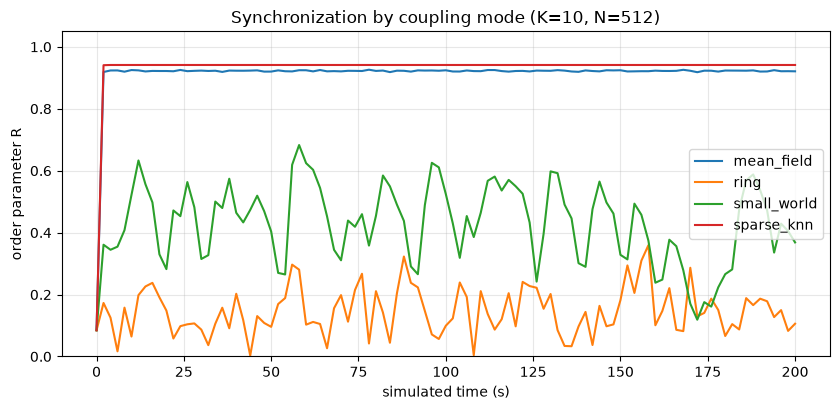

In [6]:
modes = ("mean_field", "ring", "small_world", "sparse_knn")
curves: dict[str, list[float]] = {}

for mode in modes:
    mode_sim = prin.OscilloSim(
        n_oscillators=512,
        coupling_strength=10.0,
        coupling_mode=mode,
        k_neighbors=10,
        p_rewire=0.1,
        integrator="euler",
        device=DEVICE,
        seed=SEED,
    )
    mode_res = mode_sim.run(
        n_steps=20_000, dt=0.01, record_trajectory=True, record_interval=200
    )
    curves[mode] = list(mode_res.order_parameter)
    print(f"{mode:<12} resolved={mode_res.coupling_mode:<12} "
          f"R_final={mode_res.order_parameter[-1]:.4f} "
          f"wall={mode_res.wall_time_s:.3f}s")

t_mode = np.arange(len(next(iter(curves.values())))) * 200 * 0.01
fig, ax = plt.subplots(figsize=(8.5, 4.2))
for mode in modes:
    ax.plot(t_mode, curves[mode], label=mode)
ax.set_xlabel("simulated time (s)")
ax.set_ylabel("order parameter R")
ax.set_title("Synchronization by coupling mode (K=10, N=512)")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)

## 6. A chimera state on a ring

A chimera state is the coexistence of a phase-coherent domain and an
incoherent domain in an otherwise identical network. The canonical recipe
(Abrams & Strogatz 2004) is a ring with a smooth, distance-dependent cosine
coupling kernel, which `prin.simulation.cosine_coupling_kernel` supplies as an
`(N, k)` per-edge weight tensor that `OscilloSim` accepts through
`coupling_weights`.

Four diagnostics are reported together, because **no single one is sufficient**:

| Diagnostic | Meaning | Caveat |
|---|---|---|
| `local_order_parameter` | per-oscillator R over its k neighbours | the raw spatial profile |
| `chimera_index` | fraction of oscillators with local R below a threshold | also ~1 for a *fully* incoherent network |
| `strength_of_incoherence` | windowed incoherence in [0, 1] | does not distinguish chimera from turbulence |
| `bimodality_index` | Sarle's coefficient of the local-R distribution | > 5/9 is the usual bimodality cue |
| `discontinuity_measure` | chimera number eta: count of phase jumps | grows with N |

A high `chimera_index` alone therefore does **not** establish a chimera; the
spatial profile must show a *localized* incoherent domain inside a coherent
background. The seed-to-seed table below makes that variability visible rather
than hiding it behind a single lucky realization.

cosine kernel: shape=(256, 32) dtype=torch.float32 min=0.0305 max=0.0317


 seed       R   <r_i>  std r_i    chi     SI     BC  eta  n_coh  n_inc
    7  0.3377  0.5828   0.2132  0.250  0.834  0.736    9     98     42
   13  0.5081  0.6708   0.1125  0.102  0.865  0.524    6    128      0
  101  0.0886  0.5693   0.2248  0.383  0.913  0.636    7    110     44


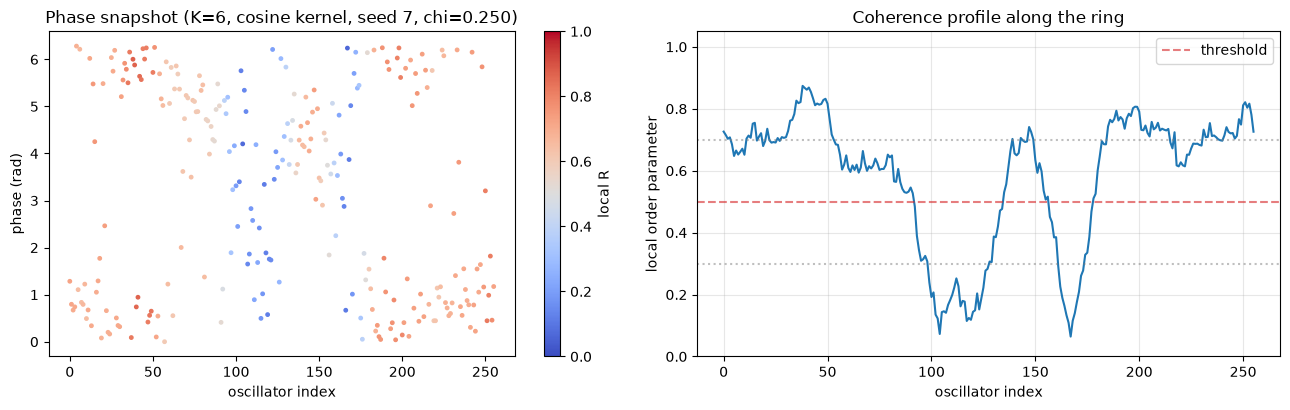

In [7]:
N_CHIMERA, K_CHIMERA = 256, 32
weights = cosine_coupling_kernel(N_CHIMERA, K_CHIMERA, A=0.995, device=DEVICE)
neighbours = prin.ring_topology(N_CHIMERA, K_CHIMERA, device=DEVICE)

print(f"cosine kernel: shape={tuple(weights.shape)} dtype={weights.dtype} "
      f"min={float(weights.min()):.4f} max={float(weights.max()):.4f}")

chimera_sweep = []
for seed in (7, 13, 101):
    c_sim = prin.OscilloSim(
        n_oscillators=N_CHIMERA,
        coupling_strength=6.0,
        coupling_mode="ring",
        k_neighbors=K_CHIMERA,
        coupling_weights=weights,
        integrator="euler",
        device=DEVICE,
        seed=seed,
    )
    c_res = c_sim.run(n_steps=40_000, dt=0.005)
    local_r = local_order_parameter(c_res.final_phase, neighbours)
    _, eta = discontinuity_measure(c_res.final_phase)
    chimera_sweep.append(
        (
            seed,
            c_res.order_parameter[-1],
            float(local_r.mean()),
            float(local_r.std()),
            chimera_index(c_res.final_phase, neighbours),
            float(strength_of_incoherence(c_res.final_phase, K_CHIMERA)),
            bimodality_index(local_r),
            eta,
            int((local_r > 0.7).sum()),
            int((local_r < 0.3).sum()),
        )
    )

print(f"{'seed':>5} {'R':>7} {'<r_i>':>7} {'std r_i':>8} {'chi':>6} {'SI':>6} "
      f"{'BC':>6} {'eta':>4} {'n_coh':>6} {'n_inc':>6}")
for row in chimera_sweep:
    print(f"{row[0]:>5} {row[1]:>7.4f} {row[2]:>7.4f} {row[3]:>8.4f} {row[4]:>6.3f} "
          f"{row[5]:>6.3f} {row[6]:>6.3f} {row[7]:>4} {row[8]:>6} {row[9]:>6}")

# Re-run the seed whose profile is plotted, so the figure and the table agree.
plot_sim = prin.OscilloSim(
    n_oscillators=N_CHIMERA,
    coupling_strength=6.0,
    coupling_mode="ring",
    k_neighbors=K_CHIMERA,
    coupling_weights=weights,
    integrator="euler",
    device=DEVICE,
    seed=7,
)
plot_res = plot_sim.run(n_steps=40_000, dt=0.005)
local_r_plot = local_order_parameter(plot_res.final_phase, neighbours)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
scatter = axes[0].scatter(
    np.arange(N_CHIMERA),
    plot_res.final_phase.numpy(),
    s=6,
    c=local_r_plot.numpy(),
    cmap="coolwarm",
    vmin=0.0,
    vmax=1.0,
)
fig.colorbar(scatter, ax=axes[0], label="local R")
axes[0].set_xlabel("oscillator index")
axes[0].set_ylabel("phase (rad)")
axes[0].set_title(
    f"Phase snapshot (K=6, cosine kernel, seed 7, chi={chimera_sweep[0][4]:.3f})"
)

axes[1].plot(local_r_plot.numpy(), color="#1f77b4")
axes[1].axhline(0.5, color="#d62728", linestyle="--", alpha=0.6, label="threshold")
axes[1].axhline(0.7, color="gray", linestyle=":", alpha=0.5)
axes[1].axhline(0.3, color="gray", linestyle=":", alpha=0.5)
axes[1].set_xlabel("oscillator index")
axes[1].set_ylabel("local order parameter")
axes[1].set_title("Coherence profile along the ring")
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()
plt.close(fig)

## Summary

| API used | What it gave you |
|---|---|
| `prin.quick_simulate` | one-call run + `throughput`, `wall_time_s`, resolved `coupling_mode` |
| `prin.OscilloSim` / `.run` | trajectory recording, `order_parameter`, `final_phase`, `final_amplitude` |
| `prin.OscilloSim(coupling_mode=...)` | `mean_field`, `ring`, `small_world`, `sparse_knn` (`auto`, `csr`; `full` is rejected) |
| `prin.simulation.cosine_coupling_kernel` | Abrams–Strogatz `(N, k)` per-edge weights |
| `prin.ring_topology` | `(N, k)` neighbour indices for the diagnostics |
| `prin.simulation.local_order_parameter` | per-oscillator local R (torch tensors in and out) |
| `prin.simulation.chimera_index` | fraction of incoherent oscillators |
| `prin.simulation.strength_of_incoherence` | windowed SI in [0, 1] |
| `prin.simulation.bimodality_index` | Sarle's BC on the local-R distribution |
| `prin.simulation.discontinuity_measure` | coherent mask + chimera number eta |

Two portability notes worth remembering. `prin.local_order_parameter` (the
top-level name) is the raw Rust owner and expects a NumPy `float64` phase
vector plus a Python list of neighbour lists; the torch-tensor wrapper used
above lives in `prin.simulation`. And `prin.kuramoto_order_parameter` is the
torch-facing wrapper — it returns a 0-dim `float64` tensor and accepts either a
tensor or an array.

A third note is a live gotcha rather than a naming quirk: `import prin` forces
matplotlib's non-interactive Agg backend, so in a notebook `%matplotlib inline`
must appear **after** the `prin` import or your figures silently produce no
output.

Next: [`02_clevr_n_binding.ipynb`](02_clevr_n_binding.ipynb) takes these
oscillators into the hierarchical delta/theta/gamma bands and trains a
multi-object tracker with them.